# Week 5 Day 3 Lab

### Problem 1
*Gradient descent* on a function $f(x)$ in the two dimensional case works as follows:
1. Start with an initial value $x_0$.
2. Compute $f'(x_0)$.
3. 
    - If $f'(x_0)>0$, move to $x_0-\epsilon$. 
    - If $f'(x_0)<0$, move to $x_0+\epsilon$. 
    - If $f'(x_0)=0$, stay put.
4. Repeat steps 1-3 for a certain amount of iterations.

Create a function that performs gradient descent. Be careful: your function should take in an iteration number so it does not run forever.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import sympy as sp

def gradient_descent(derivative,start,epsilon,iterations):
    x = start
    for i in range(iterations):
        slope = derivative(x)      
        if slope > 0:
            x = x- epsilon
        elif slope <0:
            x = x + epsilon
        else:
            x = x      
    return x

def derivative(x):
    return 2*x +6
answer = gradient_descent(derivative,0,0.01,1000)
print(answer) # this will be close to -3

-2.99999999999998


### Problem 2
Your function from above should be able to find minima. Use `%timeit` to compare the run time of your function and `minimize` from the `scipy.optimize` library. Rerun for multiple different starting points.

In [16]:
def f_scipy(x):
    return x[0]**2+6*x[0]+10

for start in [-10,0, 10]:
    my_answer = gradient_descent(derivative,start,0.01,3000)
    scipy_answer = minimize(f_scipy,x0=[start]) 
    print("starting value:", start)
    print("my gradient descent:",my_answer)
    print("scipy minimize:",scipy_answer.x)
    print() # both of these should find something close to -3
    %timeit gradient_descent(derivative, 0, 0.01, 1000)
    %timeit minimize(f_scipy, x0=[0])

starting value: -10
my gradient descent: -3.000000000000149
scipy minimize: [-3.00000064]

152 μs ± 1.63 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
661 μs ± 11.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
starting value: 0
my gradient descent: -2.99999999999998
scipy minimize: [-3.00000003]

151 μs ± 5.66 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
725 μs ± 135 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
starting value: 10
my gradient descent: -2.9999999999998113
scipy minimize: [-2.99999951]

150 μs ± 1.57 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
654 μs ± 4.58 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### Problem 3
Use `%timeit` to determine the speed of fitting a regression line by minimizing the sum of squared errors. Likewise, use `%timeit` to on using `np.polyfit()`. Was there a difference in speed?

[1.69999997 0.70000009]


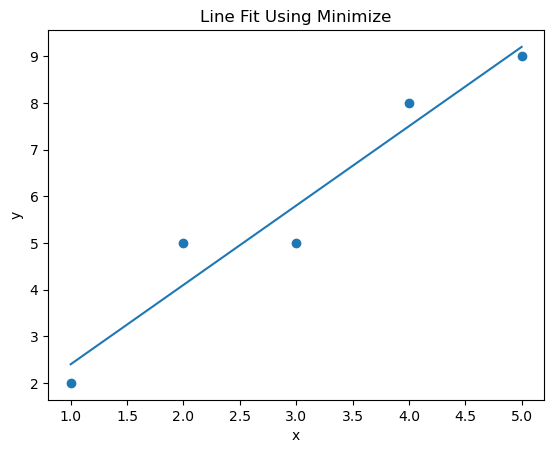

[1.7 0.7]
2.08 ms ± 9.34 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
55.2 μs ± 307 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [14]:
x = np.array([1,2,3,4,5])
y = np.array([2,5,5,8,9])

def loss(params):
    m,b = params
    prediction = m*x + b
    return np.sum((y-prediction)**2)

result = minimize(loss,[1,1])
print(result.x)
m,b = result.x

plt.scatter(x,y)
plt.plot(x,m*x +b)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Line Fit Using Minimize")
plt.show() # this gives about slope 1.7 and intercept 0.7

poly_answer = np.polyfit(x,y,1)
print(poly_answer) # np.polyfit gives about th same answer
%timeit minimize(loss, [1,1])
%timeit np.polyfit(x, y, 1)

### Problem 4 
The `loss()` function from lecture uses SSE as its error function. Define a new function `loss_2()` using a different error function. Plot the resulting lines for `loss()` and `loss_2()` on an example dataset.

SSE line
1.6999999673429407 0.7000000927518523
Absolute error line
1.750383743327078 0.24987265185353055


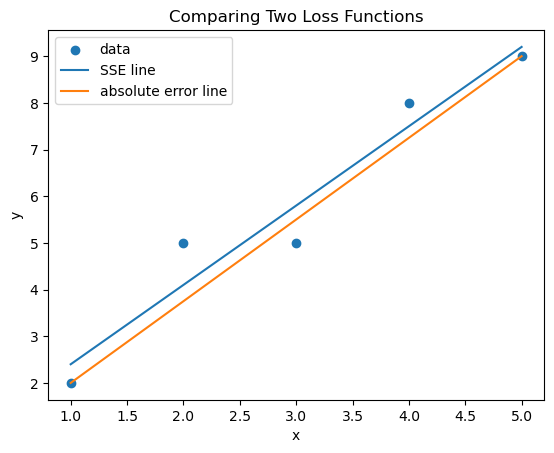

In [15]:
def loss_2(params):
    m, b = params
    prediction = m*x + b
    return np.sum(abs(y-prediction))

result_sse = minimize(loss, [1,1])
result_abs = minimize(loss_2, [1,1])
m1, b1 = result_sse.x
m2, b2 = result_abs.x

print("SSE line")
print(m1, b1)
print("Absolute error line")
print(m2, b2)

plt.scatter(x, y, label="data")
plt.plot(x, m1*x + b1,label="SSE line")
plt.plot(x, m2*x + b2,label="absolute error line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparing Two Loss Functions")
plt.legend()
plt.show() # the two lines are similar, but they do not have to be exactly the same. changing the loss function can change the fitted line